In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from arc_agi2_fun.data import load_official_split
from arc_agi2_fun.tensors import (
    NUM_COLORS,
    evaluate_tensor,
    get_task_grid,
    grid_to_tensor,
    tensor_to_grid,
)
from arc_agi2_fun.visualize import plot_grid, plot_task

DATA_DIR = ROOT / 'data' / 'ARC-AGI-2'
print('repo:', ROOT)
print('data:', DATA_DIR)

repo: /home/logankelsch/logxco/competitions/ARC-AGI-2_For_Fun
data: /home/logankelsch/logxco/competitions/ARC-AGI-2_For_Fun/data/ARC-AGI-2


1000 tasks loaded from training
first 20 ids: ['00576224', '007bbfb7', '009d5c81', '00d62c1b', '00dbd492', '017c7c7b', '025d127b', '03560426', '045e512c', '0520fde7', '05269061', '05a7bcf2', '05f2a901', '0607ce86', '0692e18c', '06df4c85', '070dd51e', '08ed6ac7', '09629e4f', '0962bcdd']
selected: 00d62c1b
train examples: 5
test examples: 1


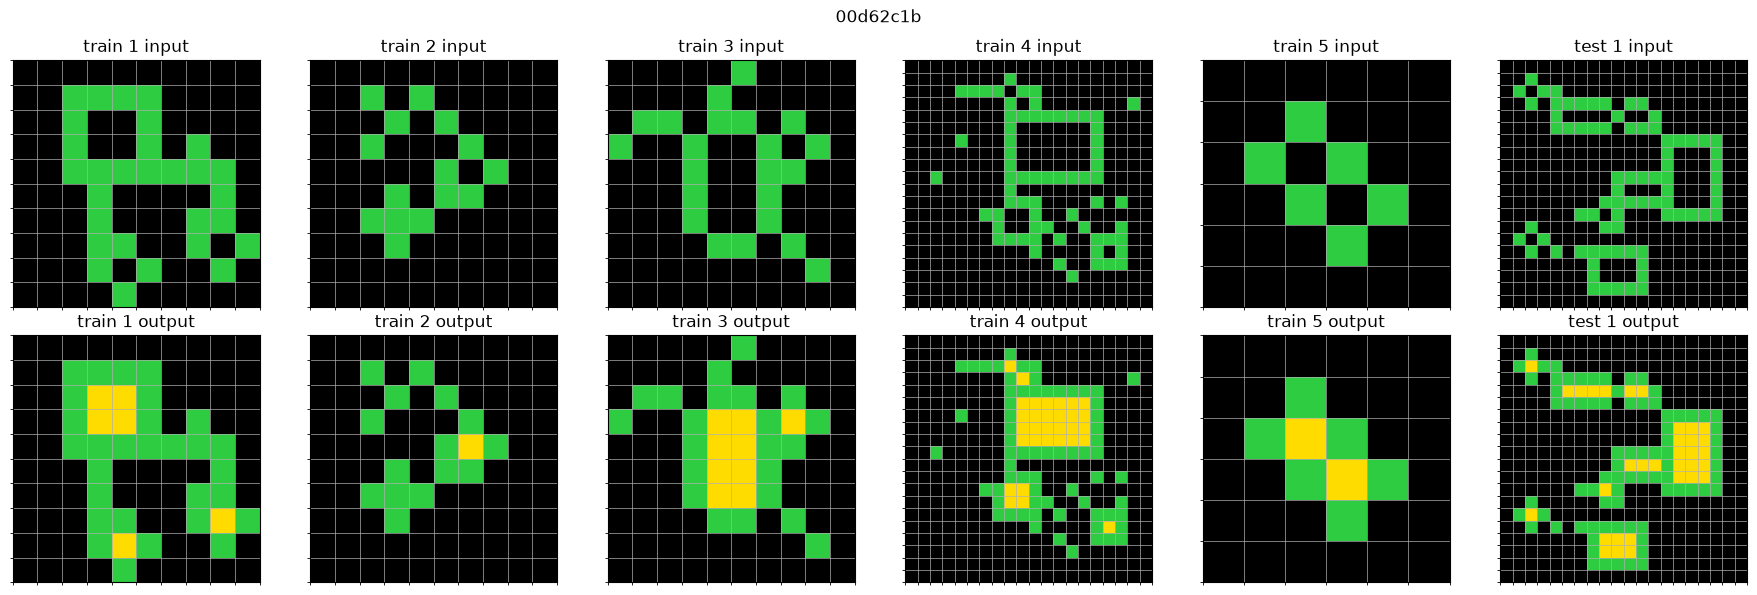

In [3]:
SPLIT = 'training'  # 'training' or 'evaluation'

tasks = load_official_split(DATA_DIR, SPLIT)
task_ids = list(tasks)
print(f'{len(task_ids)} tasks loaded from {SPLIT}')
print('first 20 ids:', task_ids[:20])

for i in range(3,4):
    TASK_ID = task_ids[i]  # replace with any id printed above
    task = tasks[TASK_ID]
    print('selected:', TASK_ID)
    print('train examples:', len(task.train))
    print('test examples:', len(task.test_inputs))

    plot_task(task)
    plt.show()

In [20]:
from ops import (
    init_env,
    GP_generate,
    SP_generate,
    get_GP_pool,
    get_ST_unsovled_frontier,
)

import pandas as pd


# --------------------------------------------------
# Initialize environment from task.train
# --------------------------------------------------

GP_meta, GP_X, SP_meta, SP_X, ST = init_env(task.train)


# --------------------------------------------------
# Expand GP by 10 genes
# --------------------------------------------------

new_gp_gidx = GP_generate(
    GP_meta,
    GP_X,
    n_new_genes=100,
    rng=42,
)


# --------------------------------------------------
# Perform one SP generation step
# --------------------------------------------------

new_sp_gidx = SP_generate(
    SP_meta,
    SP_X,
    ST,
    rng=42,
)


# --------------------------------------------------
# Show current Boolean Solution Tree
# --------------------------------------------------

display(
    pd.DataFrame(ST.rows()).set_index("node_id")
)

,label,sp_gidx,op,dims,source,gp_gidx,solution_rule,solution_params,directly_solved,solved,needs_gp_solution,derivation
node_id,,,,,,,,,,,,
0,root,0.0,raw_output,2,-1.0,-1,None,{},False,False,False,((inv_partition_shape✓ AND shape AND composite))
1,h,1.0,partition_shape,0,0.0,-1,None,{},False,False,True,NaN
2,w,2.0,partition_shape,0,0.0,-1,None,{},False,False,True,NaN
3,sp_3:partition_composite,3.0,partition_composite,0,0.0,-1,None,{},False,False,True,NaN
4,sp_4:partition_composite,4.0,partition_composite,2,0.0,-1,None,{},False,False,False,((inv_dim1_flip✓ AND 9))
5,sp_5:partition_composite,5.0,partition_composite,0,0.0,-1,None,{},False,False,True,NaN
6,sp_6:partition_composite,6.0,partition_composite,2,0.0,-1,None,{},False,False,True,NaN
7,sp_7:partition_composite,7.0,partition_composite,0,0.0,-1,None,{},False,False,True,NaN
8,sp_8:partition_composite,8.0,partition_composite,2,0.0,-1,None,{},False,False,True,NaN


In [21]:
# --------------------------------------------------
# Retrieve complete computation / matching pools
# --------------------------------------------------

GP_pool = get_GP_pool(
    GP_meta,
    GP_X,
    max_dim=0
)

ST_frontier = get_ST_unsovled_frontier(
    ST,
    SP_X,
    max_dim=0
)

In [22]:
print(len(GP_pool))
for i in range(len(GP_pool)):
    print((GP_pool[i].astype(float)))

print()
print(len(ST_frontier))
for i in range(len(ST_frontier)):
    print((ST_frontier[i].astype(float)))

7
[10. 10. 10. 20.  6.]
[10. 10. 10. 20.  6.]
[0. 0. 0. 0. 0.]
[3. 3. 3. 3. 3.]
[29. 15. 22. 67.  6.]
[ 81.  91.  92. 347.  30.]
[ 62.  82.  72. 300.  30.]

5
[10. 10. 10. 20.  6.]
[10. 10. 10. 20.  6.]
[0. 0. 0. 0. 0.]
[3. 3. 3. 3. 3.]
[4. 4. 4. 4. 4.]


In [23]:
from ops import (
    get_GP_pool,
    get_ST_unsovled_frontier,
    solve_0dim_1gene_basic,
)

import pandas as pd


GP_pool_0d = get_GP_pool(
    GP_meta,
    GP_X,
    min_dim=0,
    max_dim=0,
)

ST_frontier_0d = get_ST_unsovled_frontier(
    ST,
    SP_X,
    min_dim=0,
    max_dim=0,
)


solutions = solve_0dim_1gene_basic(
    GP_pool_0d,
    ST_frontier_0d,
    GP_X=GP_X,
    SP_X=SP_X,
    ST=ST,
)


display(
    pd.DataFrame(ST.rows()).set_index("node_id")
)

,label,sp_gidx,op,dims,source,gp_gidx,solution_rule,solution_params,directly_solved,solved,needs_gp_solution,derivation
node_id,,,,,,,,,,,,
0,root,0.0,raw_output,2,-1.0,-1,NaN,{},False,False,False,((inv_partition_shape✓ AND shape AND composite))
1,h,1.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
2,w,2.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
3,sp_3:partition_composite,3.0,partition_composite,0,0.0,3,identity,{},True,True,False,NaN
4,sp_4:partition_composite,4.0,partition_composite,2,0.0,-1,NaN,{},False,False,False,((inv_dim1_flip✓ AND 9))
5,sp_5:partition_composite,5.0,partition_composite,0,0.0,5,identity,{},True,True,False,NaN
6,sp_6:partition_composite,6.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN
7,sp_7:partition_composite,7.0,partition_composite,0,0.0,5,add_constant,{'c': 1},True,True,False,NaN
8,sp_8:partition_composite,8.0,partition_composite,2,0.0,-1,NaN,{},False,False,True,NaN


In [24]:
ST_frontier = get_ST_unsovled_frontier(
    ST,
    SP_X,
)

print(len(ST_frontier))

5


In [30]:
print((SP_X[4][0]))

[[ True  True  True  True  True  True  True  True  True  True]
 [ True  True False False False False  True  True  True  True]
 [ True  True False False False False  True  True  True  True]
 [ True  True False False False False  True False  True  True]
 [ True  True False False False False False False False  True]
 [ True  True  True False  True  True  True  True False  True]
 [ True  True  True False  True  True  True False False  True]
 [ True  True  True False False  True  True False False False]
 [ True  True  True False False False  True  True False  True]
 [ True  True  True  True False  True  True  True  True  True]]


In [25]:
from ops import (
    get_GP_pool,
    get_ST_unsovled_frontier,
    solve_2dim_1gene_basic,
)

import pandas as pd


# 2D boolean candidate genes generated from the input side
GP_pool_2d_bool = get_GP_pool(
    GP_meta,
    GP_X,
    min_dim=2,
    max_dim=2,
    dtype=bool,
)


# Unresolved 2D boolean targets on the solution side
ST_frontier_2d_bool = get_ST_unsovled_frontier(
    ST,
    SP_X,
    min_dim=2,
    max_dim=2,
    dtype=bool,
)


# Attempt exact minimum-complexity spatial solutions
solutions_2d = solve_2dim_1gene_basic(
    GP_pool_2d_bool,
    ST_frontier_2d_bool,
    GP_X=GP_X,
    SP_X=SP_X,
    ST=ST,
)


# Inspect discovered relationships
for solution in solutions_2d:
    print(
        f"SP {solution.sp_gidx} <- GP {solution.gp_gidx}: "
        f"{solution.expression}"
    )


# Inspect updated Boolean solution structure
display(
    pd.DataFrame(ST.rows()).set_index("node_id")
)

SP 6 <- GP 6: Y = X
SP 8 <- GP 22: Y = X


,label,sp_gidx,op,dims,source,gp_gidx,solution_rule,solution_params,directly_solved,solved,needs_gp_solution,derivation
node_id,,,,,,,,,,,,
0,root,0.0,raw_output,2,-1.0,-1,NaN,{},False,False,False,((inv_partition_shape✓ AND shape AND composite))
1,h,1.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
2,w,2.0,partition_shape,0,0.0,1,identity,{},True,True,False,NaN
3,sp_3:partition_composite,3.0,partition_composite,0,0.0,3,identity,{},True,True,False,NaN
4,sp_4:partition_composite,4.0,partition_composite,2,0.0,-1,NaN,{},False,False,False,((inv_dim1_flip✓ AND 9))
5,sp_5:partition_composite,5.0,partition_composite,0,0.0,5,identity,{},True,True,False,NaN
6,sp_6:partition_composite,6.0,partition_composite,2,0.0,6,identity,{},True,True,False,NaN
7,sp_7:partition_composite,7.0,partition_composite,0,0.0,5,add_constant,{'c': 1},True,True,False,NaN
8,sp_8:partition_composite,8.0,partition_composite,2,0.0,22,identity,{},True,True,False,NaN


In [26]:
from ops import Kelschinator

kelschinator = Kelschinator()

fit_success = kelschinator.fit(ST)

print("Fit success:", fit_success)

if not fit_success:
    print(kelschinator.last_error_)
else:
    y_hat = kelschinator.transform(task.test[0].input)

    print("Pipeline:")
    for step in kelschinator.pipeline_:
        print(" ", step)

    display(y_hat)

Fit success: False
SolutionTree is not fully solved.
